## Part 1, ML-model mid-time predictions.

В нашей задаче мы предсказываем поведение цены на следующий день, соответственно решаем задачу классификации.
Пройдемся последовательно по всем пунктам.

#### 1. Сбор данных

Для сбора котировок будем использовать API Yahoo Finance.
Для удобства анализа окном по 720 точек возьмем данные за бОльший период, нежели за 6месяцев.
Данные будем скачивать асинхронно.


In [1]:
! python3 --version

Python 3.12.6


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [3]:
# Тикеры собраны с сайта
# https://github.com/shilewenuw/get_all_tickers/blob/master/get_all_tickers/EU_tickers.csv
tickers = pd.read_csv('EU-tickers.csv', header=None)[0].tolist()[1:]
len(tickers)

110

In [4]:
import yfinance as yf
import asyncio
import logging

logging.getLogger("yfinance").setLevel(logging.CRITICAL)


async def download_ticker(ticker):
    return yf.download(ticker, period='6mo', interval='1h', progress=False).Close


async def download_tickers(tickers):
    tasks = [asyncio.create_task(download_ticker(ticker)) for ticker in tickers]
    results = await asyncio.gather(*tasks)
    return results

In [5]:
# try_down = 500
data = await download_tickers(tickers)
data = {tickers[i]: data[i] for i in range(len(tickers))}

Неплохо, 200 попыток скачивания в ассинхронном режиме отработали всего за 4мин16сек

In [6]:
# Удаляем пустые тиекры, меняем Timestamp
tickers_to_remove = []
for ticker in data:
    if data[ticker].empty or len(data[ticker]) < 100 or ticker == 'ADXN':
        tickers_to_remove.append(ticker)

for ticker in tickers_to_remove:
    del data[ticker]

for ticker in data:
    try:
        data[ticker].index = data[ticker].index.strftime('%y-%m-%d %H')
    except:
        print(ticker)

In [7]:
len(data)

110

In [8]:
data.keys()

dict_keys(['AXNX', 'AMED', 'AY', 'AGNC', 'AGNCN', 'ADP', 'LNT', 'ACT', 'AKAM', 'ACGLO', 'ADBE', 'ARCC', 'AMGN', 'BIDU', 'GOLD', 'TEAM', 'ARGX', 'ARLP', 'GOOGL', 'GOOG', 'BBSI', 'ADUS', 'ANSS', 'ASUR', 'BCPC', 'BIIB', 'UHAL', 'ALKS', 'TCPC', 'AVT', 'AMSWA', 'AMSF', 'ABCB', 'BLKB', 'BANF', 'BMRC', 'ADSK', 'BGNE', 'AMPH', 'ARTNA', 'ALCO', 'AGNCP', 'BCBP', 'AAPL', 'ACIW', 'BPMC', 'ANIP', 'BLMN', 'ACTG', 'ACRS', 'QFIN', 'APA', 'APOG', 'BL', 'AFYA', 'ARCB', 'AUDC', 'AMRN', 'BNTX', 'BOKF', 'ALGN', 'ITEQ', 'ALTR', 'ALDX', 'AUB', 'ASND', 'ALRS', 'ANIK', 'AGNCO', 'AMAL', 'ASTE', 'ACHC', 'ALIT', 'BECN', 'AVNW', 'AZPN', 'BANR', 'OZK', 'APDN', 'AGIO', 'IBUY', 'BCML', 'BILI', 'ACAD', 'SRCE', 'AMAT', 'CRMT', 'ANGO', 'TECH', 'ACMR', 'AAL', 'AMTB', 'AXSM', 'ATIF', 'AXGN', 'AEIS', 'ATEX', 'BLUE', 'ALRM', 'APPF', 'AMRK', 'ACLS', 'AAON', 'AVXL', 'RKDA', 'BFC', 'AMZN', 'ETNB', 'ADI', 'ASML'])

In [9]:
data['AXNX'].shape

(886,)

In [10]:
data['AXNX'].head()

Datetime
24-03-27 15    68.904999
24-03-28 09    68.970001
24-03-28 10    69.000000
24-03-28 11    68.980003
24-03-28 12    68.932503
Name: Close, dtype: float64

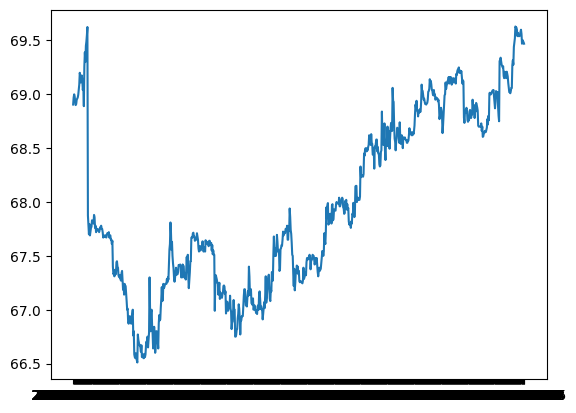

In [11]:
plt.plot(data['AXNX']);

Выглядит правдоподобно.

#### 2. Формирование окон

Разбиваем данные на окна

In [12]:
window_size = 120
train_data = {}
test_data = {}

for ticker in tqdm(data):
    df = data[ticker].values
    num_windows = len(df) - window_size
    split_idx = int(num_windows * 0.8)

    windows = np.array([df[i:i + window_size] for i in range(num_windows)])

    train_windows = windows[:split_idx]
    test_windows = windows[split_idx:]

    train_data[ticker] = [train_windows[i] for i in range(len(train_windows))]
    test_data[ticker] = [test_windows[i] for i in range(len(test_windows))]

100%|██████████| 110/110 [00:00<00:00, 3474.98it/s]


In [13]:
# число тикеров, проверка на то, что никто не потрелся
len(train_data), len(test_data) 

(110, 110)

In [14]:
# число окон в тренировочной и тестовой выборке соотв (и их отношение)
len(train_data['AXNX']), len(test_data['AXNX']), len(train_data['AXNX']) / len(test_data['AXNX'])

(684, 172, 3.9767441860465116)

In [15]:
# вот этих ребят мы будем рассматривать
train_data.keys()

dict_keys(['AXNX', 'AMED', 'AY', 'AGNC', 'AGNCN', 'ADP', 'LNT', 'ACT', 'AKAM', 'ACGLO', 'ADBE', 'ARCC', 'AMGN', 'BIDU', 'GOLD', 'TEAM', 'ARGX', 'ARLP', 'GOOGL', 'GOOG', 'BBSI', 'ADUS', 'ANSS', 'ASUR', 'BCPC', 'BIIB', 'UHAL', 'ALKS', 'TCPC', 'AVT', 'AMSWA', 'AMSF', 'ABCB', 'BLKB', 'BANF', 'BMRC', 'ADSK', 'BGNE', 'AMPH', 'ARTNA', 'ALCO', 'AGNCP', 'BCBP', 'AAPL', 'ACIW', 'BPMC', 'ANIP', 'BLMN', 'ACTG', 'ACRS', 'QFIN', 'APA', 'APOG', 'BL', 'AFYA', 'ARCB', 'AUDC', 'AMRN', 'BNTX', 'BOKF', 'ALGN', 'ITEQ', 'ALTR', 'ALDX', 'AUB', 'ASND', 'ALRS', 'ANIK', 'AGNCO', 'AMAL', 'ASTE', 'ACHC', 'ALIT', 'BECN', 'AVNW', 'AZPN', 'BANR', 'OZK', 'APDN', 'AGIO', 'IBUY', 'BCML', 'BILI', 'ACAD', 'SRCE', 'AMAT', 'CRMT', 'ANGO', 'TECH', 'ACMR', 'AAL', 'AMTB', 'AXSM', 'ATIF', 'AXGN', 'AEIS', 'ATEX', 'BLUE', 'ALRM', 'APPF', 'AMRK', 'ACLS', 'AAON', 'AVXL', 'RKDA', 'BFC', 'AMZN', 'ETNB', 'ADI', 'ASML'])

In [16]:
type(train_data['AXNX'][1])

numpy.ndarray

#### 3. Кластеризация окон

Используем 2 метода кластеризации DTW и KMeans и сравним их с помощью Silhouette Score и Davies-Bouldin Index

Комментарий к качественному анализу
* **Silhouette Score:**  Чем ближе к 1, тем лучше кластеризация. Значение 1 означает, что объекты внутри кластера очень похожи друг на друга, а объекты из разных кластеров сильно отличаются.
* **Davies-Bouldin Index:** Чем ниже значение, тем лучше кластеризация. Он измеряет отношение расстояний внутри кластера к расстояниям между кластерами.

In [17]:
from tslearn.clustering import TimeSeriesKMeans
from sklearn.cluster import KMeans
from tslearn.metrics import dtw
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.stats import skew, kurtosis

In [18]:
def extract_features(window):
    features = [
        np.mean(window),
        np.std(window),
        np.median(window),
        np.min(window),
        np.max(window),
        skew(window),
        kurtosis(window),
    ]
    return features

In [19]:
def cluster_and_evaluate(ticker, train_data, n_clusters=3):
    # DTW 
    dtw_results = {}
    X_dtw = np.array(train_data[ticker])
    dtw_model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42)
    dtw_labels = dtw_model.fit_predict(X_dtw)
    # print(f"{ticker}_1") # debug

    # KMeans 
    kmeans_results = {}
    X_kmeans = np.array([extract_features(window) for window in train_data[ticker]])
    kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans_model.fit_predict(X_kmeans)
    # print(f"{ticker}_2") # debug

    # Estimate
    dtw_silhouette = silhouette_score(X_dtw, dtw_labels, metric=dtw)
    dtw_davies_bouldin = davies_bouldin_score(X_dtw, dtw_labels)

    kmeans_silhouette = silhouette_score(X_kmeans, kmeans_labels)
    kmeans_davies_bouldin = davies_bouldin_score(X_kmeans, kmeans_labels)

    dtw_results[ticker] = {
        'labels': dtw_labels,
        'silhouette': dtw_silhouette,
        'davies_bouldin': dtw_davies_bouldin,
    }

    kmeans_results[ticker] = {
        'labels': kmeans_labels,
        'silhouette': kmeans_silhouette,
        'davies_bouldin': kmeans_davies_bouldin,
    }

    return dtw_results, kmeans_results

Для каждого тикера подбираем оптимальную модель кластеризации и оптимальное число кластеров.

P.S. вот так считалось раньше

In [20]:
# n_clusters_range = [3, 5, 7]
# 
# best_model = {}
# 
# for ticker in tqdm(train_data):
#     best_model[ticker] = {
#         'model': None,
#         'n_clusters': None,
#         'silhouette': -1,
#         'davies_bouldin': float('inf')
#     }
# 
#     for n_clusters in n_clusters_range:
#         dtw_results, kmeans_results = cluster_and_evaluate(ticker, train_data, n_clusters)
# 
#         for model_name, results in zip(['DTW', 'KMeans'], [dtw_results, kmeans_results]):
#             silhouette = results[ticker]['silhouette']
#             davies_bouldin = results[ticker]['davies_bouldin']
# 
#             if (silhouette > best_model[ticker]['silhouette'] and
#                     davies_bouldin < best_model[ticker]['davies_bouldin']):
#                 best_model[ticker]['model'] = model_name
#                 best_model[ticker]['n_clusters'] = n_clusters
#                 best_model[ticker]['silhouette'] = silhouette
#                 best_model[ticker]['davies_bouldin'] = davies_bouldin

In [21]:
list(train_data.keys())[30]

'AMSWA'

In [22]:
train_data[list(train_data.keys())[39]]

[array([36.90000153, 37.29000092, 37.31999969, 37.23519897, 37.10499954,
        36.95999908, 36.31669998, 36.33000183, 36.29999924, 36.36999893,
        36.65999985, 36.77999878, 36.86000061, 36.5       , 36.20000076,
        36.20000076, 36.29499817, 36.16999817, 35.90999985, 35.81999969,
        35.25      , 35.47000122, 35.68999863, 35.56999969, 35.61500168,
        35.61999893, 35.77999878, 36.38000107, 36.15000153, 36.11999893]),
 array([37.29000092, 37.31999969, 37.23519897, 37.10499954, 36.95999908,
        36.31669998, 36.33000183, 36.29999924, 36.36999893, 36.65999985,
        36.77999878, 36.86000061, 36.5       , 36.20000076, 36.20000076,
        36.29499817, 36.16999817, 35.90999985, 35.81999969, 35.25      ,
        35.47000122, 35.68999863, 35.56999969, 35.61500168, 35.61999893,
        35.77999878, 36.38000107, 36.15000153, 36.11999893, 36.29000092]),
 array([37.31999969, 37.23519897, 37.10499954, 36.95999908, 36.31669998,
        36.33000183, 36.29999924, 36.36999893, 

Но считалось очень долго, поэтому было принято решение распараллелить независимые подзадачи. 

In [23]:
from joblib import Parallel, delayed

n_clusters_range = [3, 5]

best_model = {}

for ticker in tqdm(train_data):
    best_model[ticker] = {
        'model': None,
        'n_clusters': None,
        'silhouette': -1,
        'davies_bouldin': float('inf')
    }

    tasks = [delayed(cluster_and_evaluate)(ticker, train_data, n_clusters) for n_clusters in n_clusters_range]
    results = Parallel(n_jobs=-1)(tasks)

    for n_clusters, (dtw_results, kmeans_results) in zip(n_clusters_range, results):
        for model_name, results in zip(['DTW', 'KMeans'], [dtw_results, kmeans_results]):
            silhouette = results[ticker]['silhouette']
            davies_bouldin = results[ticker]['davies_bouldin']

            if (silhouette > best_model[ticker]['silhouette'] and
                    davies_bouldin < best_model[ticker]['davies_bouldin']):
                best_model[ticker]['model'] = model_name
                best_model[ticker]['n_clusters'] = n_clusters
                best_model[ticker]['silhouette'] = silhouette
                best_model[ticker]['davies_bouldin'] = davies_bouldin

100%|██████████| 110/110 [19:10<00:00, 10.46s/it]


P.S. отработало после распараллелирования за 18мин, до этого было прям совсем не хорошо.

Лучшие модели для соотв. тикеров:

In [24]:
best_mode = pd.DataFrame(pd.DataFrame(best_model).T)
best_mode.head(10)

,model,n_clusters,silhouette,davies_bouldin
AXNX,DTW,3,0.546094,0.664594
AMED,DTW,3,0.711556,0.633012
AY,DTW,3,0.805143,0.602919
AGNC,DTW,3,0.611367,0.612525
AGNCN,DTW,3,0.475513,0.899084
ADP,KMeans,3,0.655044,0.421483
LNT,DTW,3,0.565953,0.662828
ACT,DTW,3,0.570728,0.649764
AKAM,DTW,3,0.606497,0.621072
ACGLO,DTW,3,0.450895,0.874216


Чаще лучше оказывается модель динамического времени (DTW), тем не менее стандартный KMeans тоже имеет место быть.
Колво кластеров тоже чаще лучше 3 чем 5.

#### 4. Создание признаков

Для автогенерации признаков была выбрана одна из наиболее эффективных библиотек **tsfel**, тк она 

In [25]:
import tsfel

cfg = tsfel.get_features_by_domain('statistical')


def extract_features_tsfel(window):
    features_df = tsfel.time_series_features_extractor(cfg, window, fs=1, verbose=0)
    features = features_df.transpose()[0].to_dict()
    return features

Создание признаков с информацией о кластерах, обучение DTW/KMeans и предсказание кластеров для каждого тикера:


In [26]:
train_features = {}
test_features = {}

for ticker in tqdm(train_data):
    best_model_name = best_model[ticker]['model']
    best_n_clusters = best_model[ticker]['n_clusters']

    if best_model_name == 'DTW':

        best_model_instance = TimeSeriesKMeans(n_clusters=best_n_clusters, metric="dtw", random_state=42, verbose=0)
        best_model_instance.fit([window.reshape(1, -1) for window in train_data[ticker]])

        train_cluster_labels = best_model_instance.predict([window.reshape(1, -1) for window in train_data[ticker]])
        test_cluster_labels = best_model_instance.predict([window.reshape(1, -1) for window in test_data[ticker]])

    elif best_model_name == 'KMeans':
        train_features_kmeans = np.array(
            [list(extract_features_tsfel(window).values()) for window in train_data[ticker]])
        test_features_kmeans = np.array([list(extract_features_tsfel(window).values()) for window in test_data[ticker]])

        best_model_instance = KMeans(n_clusters=best_n_clusters, random_state=42, verbose=0)
        best_model_instance.fit(train_features_kmeans)

        train_cluster_labels = best_model_instance.predict(train_features_kmeans)
        test_cluster_labels = best_model_instance.predict(test_features_kmeans)

    train_features[ticker] = []
    for i, window in enumerate(train_data[ticker]):
        features = extract_features_tsfel(window)
        features['cluster'] = train_cluster_labels[i]
        train_features[ticker].append(features)

    test_features[ticker] = []
    for i, window in enumerate(test_data[ticker]):
        features = extract_features_tsfel(window)
        features['cluster'] = test_cluster_labels[i]
        test_features[ticker].append(features)


100%|██████████| 110/110 [04:16<00:00,  2.33s/it]


In [27]:
len(train_features['AXNX']) # число окон у тикера

684

In [28]:
len(train_features['AXNX'][0]) # число признаков конкретного окна тикера

32

In [30]:
train_features['AXNX'][16] # сами признаки 

{'0_Absolute energy': 140494.08368918166,
 '0_Average power': 4844.623575489023,
 '0_ECDF Percentile Count_0': 6.0,
 '0_ECDF Percentile Count_1': 24.0,
 '0_ECDF Percentile_0': 67.76000213623047,
 '0_ECDF Percentile_1': 69.26000213623047,
 '0_ECDF_0': 0.03333333333333333,
 '0_ECDF_1': 0.06666666666666667,
 '0_ECDF_2': 0.1,
 '0_ECDF_3': 0.13333333333333333,
 '0_ECDF_4': 0.16666666666666666,
 '0_ECDF_5': 0.2,
 '0_ECDF_6': 0.23333333333333334,
 '0_ECDF_7': 0.26666666666666666,
 '0_ECDF_8': 0.3,
 '0_ECDF_9': 0.3333333333333333,
 '0_Entropy': 0.9592409905818987,
 '0_Histogram mode': 67.78675231933593,
 '0_Interquartile range': 1.3825035095214844,
 '0_Kurtosis': -1.726548561996909,
 '0_Max': 69.625,
 '0_Mean': 68.4293332417806,
 '0_Mean absolute deviation': 0.7292448086208765,
 '0_Median': 67.86750030517578,
 '0_Median absolute deviation': 0.157501220703125,
 '0_Min': 67.69000244140625,
 '0_Peak to peak distance': 1.93499755859375,
 '0_Root mean square': 68.43344301562448,
 '0_Skewness': 0.36

#### 5. Разметка данных

Цену считаем стабильной если она в пределах **0.5%**


In [31]:
def calculate_trend(current_value, next_value, growth_threshold=0.005, decline_threshold=-0.005):
    change = (next_value - current_value) / current_value
    return int(change > growth_threshold) - int(change < decline_threshold)

In [32]:
# train
for ticker in train_features:
    for i in range(len(train_features[ticker]) - 1):
        curr_cost = data[ticker].iloc[window_size + i - 1]
        next_cost = data[ticker].iloc[window_size + i]
        trend = calculate_trend(curr_cost, next_cost)
        train_features[ticker][i]['trend'] = trend
        # debug info
        if ticker == 'AXNX' and i == 2:
            print(f"{curr_cost = },\n{next_cost = },\n{trend = }")

curr_cost = 67.69999694824219,
next_cost = 67.79499816894531,
trend = 0


In [33]:
# Обработаем тест
for ticker in test_features:
    for i in range(len(test_features[ticker]) - 1):
        curr_cost = data[ticker].iloc[window_size + i - 1]
        next_cost = data[ticker].iloc[window_size + i]
        trend = calculate_trend(curr_cost, next_cost)
        test_features[ticker][i]['trend'] = trend

#### 6. Обучение модели

Рассмотрим 8 моделей классификации и подберем для них оптимальные гиперпараметры поиском по сетке.

In [34]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = [
    ('RandomForest', RandomForestClassifier(random_state=42), {
        'n_estimators': [50, 100, 200],
        'max_depth': [10],
    }),
    ('SVM', SVC(random_state=42), {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
    }),
    ('CatBoost', CatBoostClassifier(random_seed=42, verbose=False), {
        'iterations': [50, 100],
        'learning_rate': [0.01, 0.1],
        'depth': [4, 6],
    }),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss'), {
        'n_estimators': [30, 50, 100],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
    }),
    ('LightGBM', LGBMClassifier(random_state=42, force_col_wise=True, verbose=-1), {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1],
        'max_depth': [5, 7],
    }),
    ('GradientBoosting', GradientBoostingClassifier(random_state=42), {
        'n_estimators': [100],
        'learning_rate': [0.01, 0.1],
        'max_depth': [5],
    }),
    ('AdaBoost', AdaBoostClassifier(algorithm='SAMME', random_state=42), {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1],
    }),
]

label_encoder = LabelEncoder()


#### 7. Оценка модели

Какую же нам метрику качества взять? У нас цель именно классифицировать тренд, поэтому достаточно accuracy

Препроцессинг перед МЛ

In [35]:
import warnings
import logging

logging.disable(logging.CRITICAL)
warnings.filterwarnings('ignore')

def data_preprocess(ticker):
    X_train = pd.DataFrame(train_features[ticker][:-1])
    y_train = pd.DataFrame(train_features[ticker][1:])['trend']
    X_train.drop(['trend'], axis=1, inplace=True)
    y_train = label_encoder.fit_transform(y_train)

    X_test = pd.DataFrame(test_features[ticker][:-1])
    y_test = pd.DataFrame(test_features[ticker][1:])['trend']
    X_test.drop(['trend'], axis=1, inplace=True)
    y_test = label_encoder.fit_transform(y_test)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
        
    return X_train, y_train, X_test, y_test
        
    

Обучение

In [36]:
results = {}

warnings.filterwarnings('ignore')

for ticker in tqdm(train_features):
    # print(f"Обработка тикера: {ticker}")
    results[ticker] = {}

    X_train, y_train, X_test, y_test = data_preprocess(ticker)

    for model_name, model, param_grid in models:
        # print(f"  - модель: {model_name}")
        warnings.filterwarnings('ignore')
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        # print(f"{best_model = }")
        y_pred = best_model.predict(X_test)
        
        results[ticker][model_name] = accuracy_score(y_test, y_pred)

100%|██████████| 110/110 [20:47<00:00, 11.34s/it]


In [58]:
# train_features[list(train_data.keys())[10]]

42минуты работало, я бы выключил варнинги, но придется опять ждать :(

In [56]:
results_df = pd.DataFrame(results).transpose()
results_df = results_df.drop(['AXNX', 'AGNCP', 'AGNCO'], axis=0)
results_df.loc['[Mean]'] = results_df.mean()
results_df = pd.concat([results_df.loc[['[Mean]']], results_df.drop('[Mean]', axis=0)])
print("\nРезультаты:")
results_df


Результаты:


,RandomForest,SVM,CatBoost,XGBoost,LightGBM,GradientBoosting,AdaBoost
[Mean],0.546401,0.624786,0.619712,0.585701,0.618129,0.507052,0.624799
AMED,0.964912,0.964912,0.964912,0.964912,0.964912,0.964912,0.964912
AY,0.485380,0.485380,0.485380,0.485380,0.485380,0.485380,0.485380
AGNC,0.795322,0.836257,0.836257,0.824561,0.836257,0.736842,0.836257
AGNCN,0.973856,0.973856,0.973856,0.973856,0.973856,0.973856,0.973856
...,...,...,...,...,...,...,...
BFC,0.500000,0.547619,0.547619,0.515873,0.547619,0.531746,0.547619
AMZN,0.736842,0.736842,0.736842,0.736842,0.736842,0.725146,0.736842
ETNB,0.309942,0.304094,0.368421,0.309942,0.269006,0.321637,0.380117
ADI,0.695906,0.719298,0.719298,0.701754,0.719298,0.672515,0.719298


In [59]:
results_df.T['[Mean]'].sort_values(ascending=False)

AdaBoost            0.624799
SVM                 0.624786
CatBoost            0.619712
LightGBM            0.618129
XGBoost             0.585701
RandomForest        0.546401
GradientBoosting    0.507052
Name: [Mean], dtype: float64

#### Выводы

Были загружены данные 120 тикеров за последние 6 месяцов с часовой частотой

Была проведена кластеризация тикеров 2-мя методами KMeans и DTW

Были выделены 32 признака, в том числе на основе кластеризации
 
На выборке из 120 тикеров все модели показали средний результат **accuracy** выше случайного (0.33)

А модели [SVM, CatBoost, LightGBM, AdaBoost, LogisticRegression] показали в среднем строго положительный результат (выше 0,5)

P.S. ввиду обилия неопределнностей и неожиданных открытий, около 80% промежуточного кода было впоследствии стёрто. Но задача крутая!